In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [ ]:
import os
import sys
import numpy as np
import pandas as pd
from PIL import Image
from tqdm import tqdm
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import autocast

import cv2
import albumentations as A
from albumentations.pytorch import ToTensorV2

from scipy.stats import wilcoxon
import warnings
warnings.filterwarnings('ignore')


C:\Users\admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)
np.random.seed(23651)
torch.manual_seed(23651)

Device: cuda


In [ ]:
from segmentation.model import (
    SegmentationBackbone,SegmentationModel,      
    val_transform,
)

print('Imported SegmentationBackbone and SegmentationModel from segmentation/model.py')


Imported SegmentationBackbone and SegmentationModel from segmentation/model.py


In [ ]:
import os

if os.path.exists("/kaggle/input"):
    BASE_PATH = "/kaggle/input/competitions/mlds-2026-assignment-2"
else:
    BASE_PATH = "../"
label_df = pd.read_csv(os.path.join(BASE_PATH, 'train/labels.csv'))

train_size = int(0.85 * len(label_df))
indices    = list(range(len(label_df)))
np.random.seed(23651)          # same seed as training
np.random.shuffle(indices)
val_indices    = indices[train_size:]
val_label_df   = label_df.iloc[val_indices]

print(f'Validation set size: {len(val_label_df)} images')

Validation set size: 330 images


In [ ]:
class SegDataset(Dataset):
    def __init__(self, image_dir, label_df, mask_dir, transform=None):
        self.image_dir = image_dir
        self.mask_dir  = mask_dir
        self.transform = transform
        self.df        = label_df.reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        image_id = self.df.iloc[idx]['image_id']
        img      = cv2.cvtColor(cv2.imread(os.path.join(self.image_dir, image_id + '.jpg')), cv2.COLOR_BGR2RGB)
        mask = np.array(Image.open(os.path.join(self.mask_dir, image_id + '.png')))
        if self.transform:
            aug  = self.transform(image=img, mask=mask)
            img  = aug['image']
            mask = aug['mask']
        return img, torch.tensor(mask).long()


val_dataset = SegDataset(
    image_dir = os.path.join(BASE_PATH, 'train/images'),
    label_df  = val_label_df,
    mask_dir  = os.path.join(BASE_PATH, 'train/segmentation_masks'),
    transform = val_transform    
)

val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False, num_workers=0, pin_memory=True)
print(f'Val loader ready — {len(val_dataset)} images, {len(val_loader)} batches')


Val loader ready — 330 images, 21 batches


In [ ]:
def load_backbone(weight_path: str) -> SegmentationBackbone:
    model = SegmentationBackbone(num_classes=21).to(device)
    model.load_state_dict(torch.load(weight_path, map_location=device))
    model.eval()
    return model

model_A = load_backbone('segmentation/weights/best_seg_model_A.pth')
model_B = load_backbone('segmentation/weights/best_seg_model_B.pth')

print('Model A loaded from segmentation/weights/best_seg_model_A.pth')
print('Model B loaded from segmentation/weights/best_seg_model_B.pth')
print(f'Parameters: {sum(p.numel() for p in model_A.parameters()):,}')


Model A loaded from segmentation/weights/best_seg_model_A.pth
Model B loaded from segmentation/weights/best_seg_model_B.pth
Parameters: 44,281,877


In [ ]:
def compute_miou(pred: np.ndarray, target: np.ndarray, num_classes: int = 21) -> float:
    ious  = []
    valid = target != 255
    for cls in range(1, num_classes):
        pm    = (pred   == cls)[valid]
        tm    = (target == cls)[valid]
        if tm.sum() == 0:
            continue
        inter = (pm & tm).sum()
        union = (pm | tm).sum()
        if union > 0:
            ious.append(inter / union)
    return float(np.mean(ious)) if ious else 1.0


def evaluate_miou(model: SegmentationBackbone, loader: DataLoader) -> np.ndarray:
    model.eval()
    scores = []
    with torch.no_grad():
        for imgs, masks in tqdm(loader, desc='Evaluating mIoU'):
            with autocast():
                out = model(imgs.to(device))
            preds = torch.argmax(out, dim=1).cpu().numpy()
            for p, t in zip(preds, masks.numpy()):
                scores.append(compute_miou(p, t))
    return np.array(scores)


In [12]:
print('Evaluating Model A on validation set...')
miou_A = np.array(evaluate_miou(model_A, val_loader))

print('\nEvaluating Model B on validation set...')
miou_B = np.array(evaluate_miou(model_B, val_loader))

print(f'\nModel A — n={len(miou_A)}, mean mIoU = {miou_A.mean():.4f}, std = {miou_A.std():.4f}')
print(f'Model B — n={len(miou_B)}, mean mIoU = {miou_B.mean():.4f}, std = {miou_B.std():.4f}')


Evaluating Model A on validation set...


Evaluating mIoU:   0%|          | 0/21 [00:00<?, ?it/s]

Evaluating mIoU: 100%|██████████| 21/21 [00:17<00:00,  1.19it/s]



Evaluating Model B on validation set...


Evaluating mIoU: 100%|██████████| 21/21 [00:11<00:00,  1.80it/s]


Model A — n=330, mean mIoU = 0.6849, std = 0.2627
Model B — n=330, mean mIoU = 0.6534, std = 0.2981


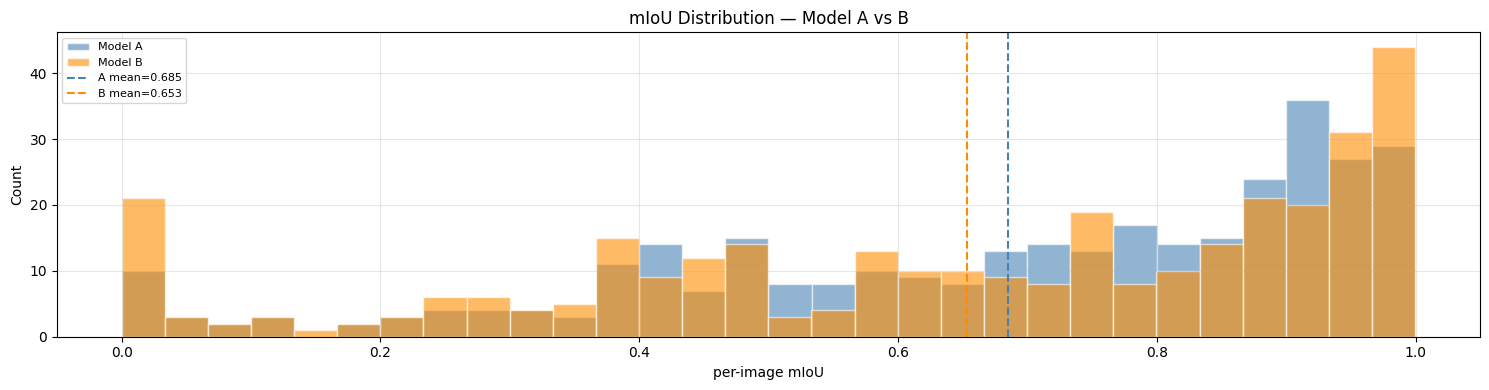

Saved: miou_distributions.png


In [ ]:
fig, axes = plt.subplots(1, 1, figsize=(15, 4))

axes.hist(miou_A, bins=30, alpha=0.6, color='steelblue', edgecolor='white', label='Model A')
axes.hist(miou_B, bins=30, alpha=0.6, color='darkorange', edgecolor='white',label='Model B')
axes.axvline(miou_A.mean(), color='steelblue',linestyle='--', linewidth=1.5, label=f'A mean={miou_A.mean():.3f}')
axes.axvline(miou_B.mean(), color='darkorange', linestyle='--', linewidth=1.5,label=f'B mean={miou_B.mean():.3f}')

axes.set_xlabel('per-image mIoU')
axes.set_ylabel('Count')
axes.set_title('mIoU Distribution — Model A vs B')
axes.legend(fontsize=8)
axes.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('miou_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

print('Saved: miou_distributions.png')


---
## Part A — Wilcoxon Signed-Rank Test

### Hypotheses

| | |
|---|---|
| **H₀** | There is no significant difference between the per-image mIoU of Model A and Model B. |
| **H₁** | There IS a significant difference between the per-image mIoU of Model A and Model B. |


In [14]:
diff = miou_A - miou_B

In [ ]:
print('Wilcoxon Signed-Rank Test')
print()
print(f'H₀: mIoU(A) = mIoU(B)  (no significant difference)')
print(f'H₁: mIoU(A) ≠ mIoU(B)  (significant difference exists)')
print(f'Significance level α = 0.05')
print()

stat_w, p_w = wilcoxon(miou_A, miou_B)

print(f'Wilcoxon statistic : {stat_w:.4f}')
print(f'p-value            : {p_w:.6f}')
print()
if p_w < 0.05:
    print('-> Reject H₀ at α = 0.05.')
    print(f'  The two models differ significantly in per-image mIoU.')
    better = 'A' if miou_A.mean() > miou_B.mean() else 'B'
    print(f'Model {better} performs significantly better (mean mIoU: A={miou_A.mean():.4f}, B={miou_B.mean():.4f}).')
else:
    print('-> Fail to reject H₀ at α = 0.05.')
    print('  No statistically significant difference detected between the two models.')

print()
print(f'Mean difference   (A - B): {diff.mean():.4f}')
print(f'Median difference (A - B): {np.median(diff):.4f}')
print(f'Std of differences       : {diff.std():.4f}')


Wilcoxon Signed-Rank Test

H₀: mIoU(A) = mIoU(B)  (no significant difference)
H₁: mIoU(A) ≠ mIoU(B)  (significant difference exists)
Significance level α = 0.05

Wilcoxon statistic : 24258.0000
p-value            : 0.220603

-> Fail to reject H₀ at α = 0.05.
  No statistically significant difference detected between the two models.

Mean difference   (A − B): 0.0315
Median difference (A − B): 0.0000
Std of differences       : 0.1929


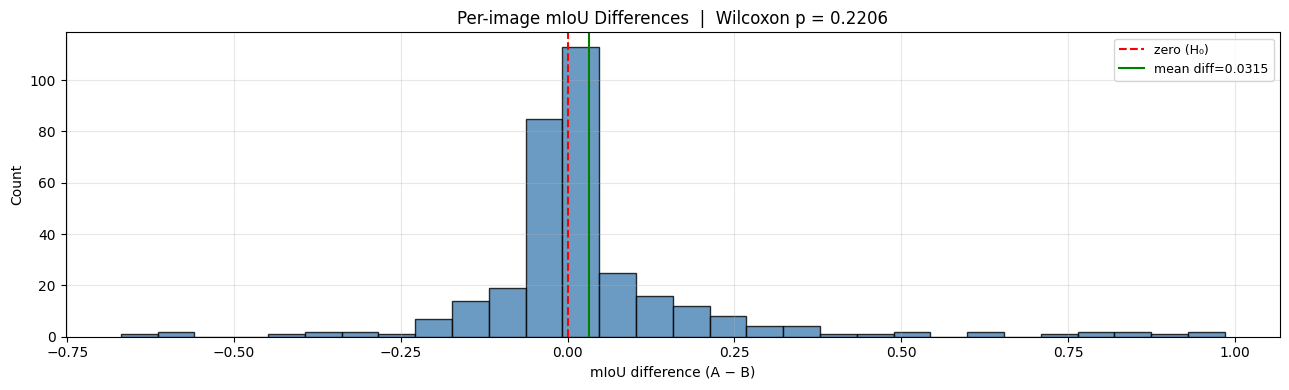

Saved: wilcoxon_diff_histogram.png


In [ ]:
fig, axes = plt.subplots(1, 1, figsize=(13, 4))

# Histogram 
axes.hist(diff, bins=30, edgecolor='black', color='steelblue', alpha=0.8)

axes.axvline(0, color='red', linestyle='--', linewidth=1.5, label='zero (H₀)')
axes.axvline(diff.mean(), color='green', linestyle='-', linewidth=1.5,label=f'mean diff={diff.mean():.4f}')

axes.set_xlabel('mIoU difference (A − B)')
axes.set_ylabel('Count')
axes.set_title(f'Per-image mIoU Differences  |  Wilcoxon p = {p_w:.4f}')
axes.legend(fontsize=9)
axes.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('wilcoxon_diff_histogram.png', dpi=150, bbox_inches='tight')
plt.show()

print('Saved: wilcoxon_diff_histogram.png')

---
## Part B — Bootstrap 95% Confidence Interval on mIoU

We compute a **percentile bootstrap** 95% CI on the overall mean mIoU
of the **better-performing** model (determined by mean mIoU on the validation set).


In [ ]:
# Select the better model
if miou_A.mean() >= miou_B.mean():
    best_miou_list = miou_A
    model_name_str = 'A'
else:
    best_miou_list = miou_B
    model_name_str = 'B'

overall_miou = best_miou_list.mean()
print(f'Better model: Model {model_name_str}')
print(f'Overall mIoU (Model {model_name_str}): {overall_miou:.4f}')


Better model: Model A
Overall mIoU (Model A): 0.6849


In [17]:
B_BOOT = 10_000     # number of bootstrap resamples
n      = len(best_miou_list)
rng    = np.random.default_rng(23651)

boot_means = np.array([
    rng.choice(best_miou_list, size=n, replace=True).mean()
    for _ in range(B_BOOT)
])

boot_mean = boot_means.mean()
boot_se   = boot_means.std()
ci_lo     = np.percentile(boot_means, 2.5)
ci_hi     = np.percentile(boot_means, 97.5)

print(f'Bootstrap resamples    : {B_BOOT:,}')
print(f'Original mean mIoU     : {overall_miou:.4f}')
print(f'Bootstrap mean         : {boot_mean:.4f}')
print(f'Bootstrap std error    : {boot_se:.4f}')
print(f'95% CI (percentile)    : [{ci_lo:.4f},  {ci_hi:.4f}]')
print(f'CI width               : {ci_hi - ci_lo:.4f}')


Bootstrap resamples    : 10,000
Original mean mIoU     : 0.6849
Bootstrap mean         : 0.6848
Bootstrap std error    : 0.0143
95% CI (percentile)    : [0.6566,  0.7127]
CI width               : 0.0561


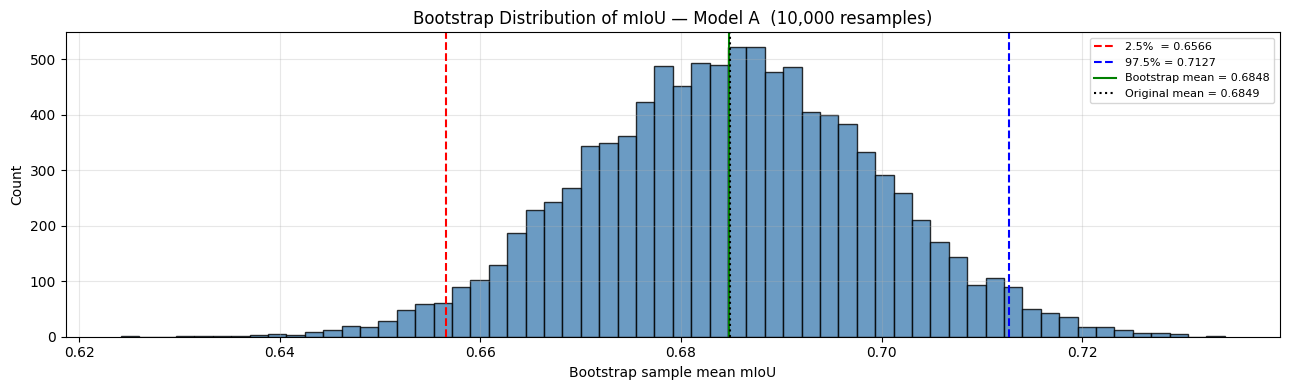

Saved: bootstrap_miou.png


In [ ]:
fig, axes = plt.subplots(1, 1, figsize=(13, 4))

axes.hist(boot_means, bins=60, edgecolor='black', color='steelblue', alpha=0.8)
axes.axvline(ci_lo,color='red',linestyle='--', linewidth=1.5, label=f'2.5%  = {ci_lo:.4f}')
axes.axvline(ci_hi,color='blue',  linestyle='--', linewidth=1.5, label=f'97.5% = {ci_hi:.4f}')
axes.axvline(boot_mean,color='green', linestyle='-',linewidth=1.5, label=f'Bootstrap mean = {boot_mean:.4f}')
axes.axvline(overall_miou,color='black', linestyle=':',linewidth=1.5, label=f'Original mean = {overall_miou:.4f}')
axes.set_xlabel('Bootstrap sample mean mIoU')
axes.set_ylabel('Count')
axes.set_title(f'Bootstrap Distribution of mIoU — Model {model_name_str}  ({B_BOOT:,} resamples)')
axes.legend(fontsize=8); axes.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('bootstrap_miou.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: bootstrap_miou.png')
